# AI Ethics Project - complete

Personalization is a central aspect of many core AI systems. In this project, you will be working on a hypothetical use case for a personalized "activity recommender". The use case has a medium ethical AI risk level and involves a synthetic dataset.

IDOOU is a mobile app users can leverage to get recommendations on activities they can take in a given area, like “visiting a movie theater”, “visiting a park”, “sightseeing”, “hiking”, or “visiting a library”.


**Problem statement**:

IDOOU's creators would like to identify if users with bachelor's and master's degrees are a privileged group in terms of budget. In other words, do users with higher education credentials beyond high school have a budget >= $300 compared to users of the app who graduated from high school? 

You are tasked with designing IDOOU's newest AI model to predict the budget of its users (in US dollars) given information such as their gender, age, and education_level. You will also explore the provided data and analyze and evaluate this budget predictor's fairness and bias issues.


**Key points**:

- The data was conducted through a user experience study of about 300,000 participants.
- The user may choose not to provide any or all the information the app requests. The training data also reflects this.
- Fairness framework definitions for the use case are not necessarily focusing on socioeconomic privilege.

In [1]:
# Only for running code in workspace
# !pip install aif360
# !pip install tensorflow
# !pip install jinja2
# !pip install fairlearn
# !pip install 'aif360[LawSchoolGPA]'

**Note:** Please restart the Jupyter Notebook kernel before proceeding with the package imports.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import tempfile
from aif360.datasets import StandardDataset, BinaryLabelDataset
from aif360.metrics import ClassificationMetric, BinaryLabelDatasetMetric
from sklearn.tree import DecisionTreeClassifier
from aif360.algorithms.postprocessing import RejectOptionClassification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import joblib
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.inspection import permutation_importance

# Settings
color = 'orange'


pip install 'aif360[inFairness]'


In [3]:
# Loading the dataset for this project
act_rec_dataset = pd.read_csv('udacity_ai_ethics_project_data.csv')
act_rec_dataset.head(20)


,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
1,1741.0,89.0,Other,Bachelor’s Degree,NaN,Play: Visit a movie theater
2,140.0,22.0,NaN,Other,0.0,Play: Visit a movie theater
3,179.0,23.0,Non-binary,Other,0.0,Play: Visit a movie theater
4,3479.0,79.0,Non-binary,Master’s Degree,1.0,Learn: Visit a library
5,3335.0,35.0,Male,Bachelor’s Degree,1.0,Play: Go shopping
6,4044.0,42.0,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing
7,3110.0,33.0,NaN,Bachelor’s Degree,NaN,Learn: Visit a library
8,2410.0,30.0,Transgender,Master’s Degree,1.0,Stay in: Color
9,4133.0,43.0,Transgender,Master’s Degree,1.0,Stay in: Color


## Step 1: Data Pre-Processing and Evaluation

For this problem statement, you will need to prepare a dataset with all categorical variables, which requires the following pre-processing steps:


- Remove the NA values from the dataset
- Convert Age and Budget (in dollars) to categorical columns with the following binning:

> Bins for Age: 18-24, 25-44, 45-65, 66-92

> Bins for Budget: >=300, <300

In [4]:
# Dataframe pre-processing
# Removal of the NA values
act_rec_dataset = act_rec_dataset.dropna()

# Convert Age and Budget (in dollars) to categorical columns with the following bins:
# Bins for age: 18-24, 25-44, 45-65, 66-92
act_rec_dataset['Age'] = pd.cut(
    act_rec_dataset['Age'],
    bins=[18, 24, 44, 65, 92],
    labels=['18-24', '25-44', '45-65', '66-92'],
    include_lowest=True # include the 18 year old in the 18-24 bin
)
# bins for budget: >=300, <300
act_rec_dataset['Budget (in dollars)'] = pd.cut(
    act_rec_dataset['Budget (in dollars)'],
    bins=[0, 300, float('inf')],
    labels=['<300', '>=300'],
    right=False # include the 300 in the >=300 bin
)

act_rec_dataset.head(20)


,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,>=300,25-44,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
3,<300,18-24,Non-binary,Other,0.0,Play: Visit a movie theater
4,>=300,66-92,Non-binary,Master’s Degree,1.0,Learn: Visit a library
5,>=300,25-44,Male,Bachelor’s Degree,1.0,Play: Go shopping
6,>=300,25-44,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing
8,>=300,25-44,Transgender,Master’s Degree,1.0,Stay in: Color
9,>=300,25-44,Transgender,Master’s Degree,1.0,Stay in: Color
11,<300,18-24,Other,High School Grad,1.0,Play: Go shopping
13,<300,18-24,Other,High School Grad,0.0,Play: Go shopping
17,<300,18-24,Male,Did Not Graduate HS,1.0,Play: Visit a movie theater


### Evaluate bias issues in the dataset

Next, let's take a look at potential hints of data bias in the variables, particularly the "Gender", "Age", and "Education" variables.

Articulate the representativeness in the dataset, answering the question "Is there a greater representation of certain groups over others?"

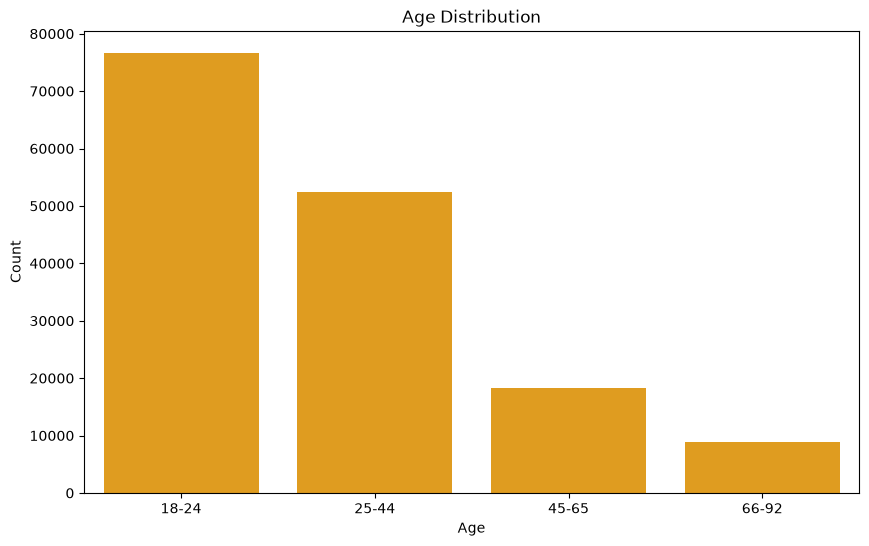

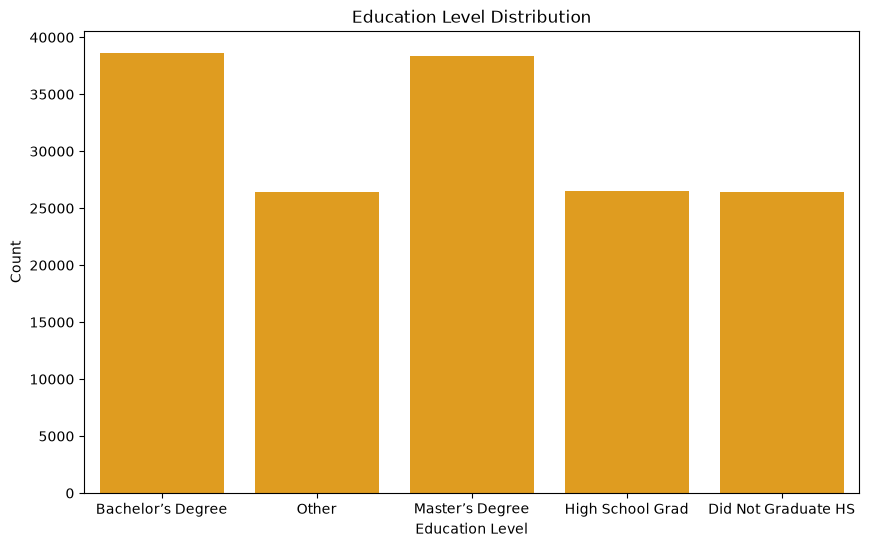

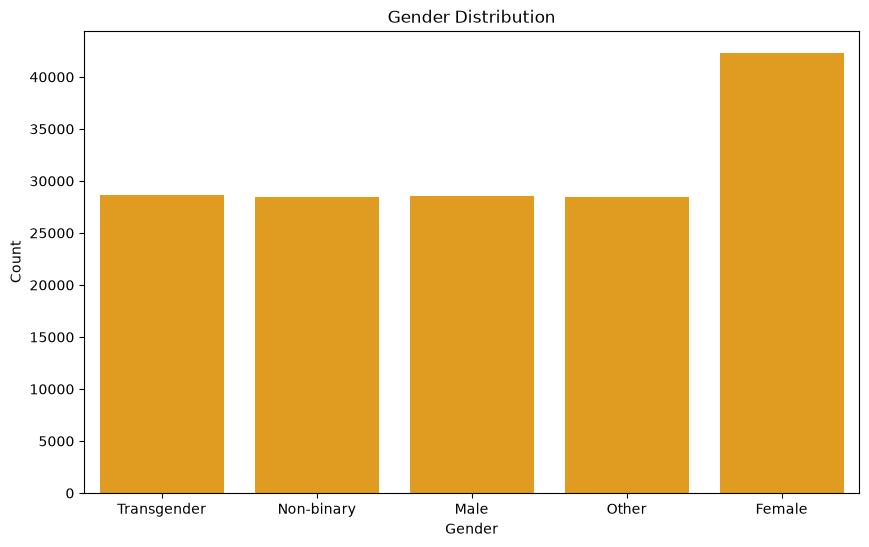

In [5]:
#Generate visualizations to understand the representativeness of the dataset

# Plot the age distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Age', data=act_rec_dataset, ax=ax, color=color)
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.show()

# Plot the education level distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Education_Level', data=act_rec_dataset, ax=ax, color=color)
ax.set_title('Education Level Distribution')
ax.set_xlabel('Education Level')
ax.set_ylabel('Count')
plt.show()

# Plot the gender distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Gender', data=act_rec_dataset, ax=ax, color=color)
ax.set_title('Gender Distribution')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
plt.show()


Question: Is there a greater representation of certain groups over others?

**Your answer:**

Yes, age is the strongest imbalance with about half the rows belonging to the 18-24 age group while older users are underrepresented. Education has a strong imbalance with bachelor and master graduates overrepresented (vs. high school graduates). Gender is less imbalanced with only female users slightly overrepresented. There is selection bias toward young, higher-education users. Dropping incomplete rows (skipped gender, education, or with children) is also sampling bias, so the remaining data does not represent the full app population.


Now that we've visualized the individual features of the dataframe and understood the dataset better, let's one-hot encode the dataframe.

In [6]:
#The variable act_rec_dataset should contain the one-hot encoded variables
act_rec_dataset = pd.get_dummies(act_rec_dataset, columns=['Age', 'Education_Level', 'Gender', 'Budget (in dollars)', 'Recommended_Activity'], dtype=int)
act_rec_dataset


,With children?,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Education_Level_Bachelor’s Degree,Education_Level_Did Not Graduate HS,Education_Level_High School Grad,Education_Level_Master’s Degree,Education_Level_Other,...,Budget (in dollars)_>=300,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,0.0,0,1,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0.0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,1.0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,1,0,0,0,0,0
5,1.0,0,1,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
6,0.0,0,1,0,0,0,0,0,1,0,...,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299984,1.0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
299989,1.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
299990,0.0,0,1,0,0,1,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
299995,0.0,0,0,1,0,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0


Visualize the interactions between the categorical variables. Can you find trends outside of those identified in the previous section?

**Hint**: Use a multicollinearity matrix.

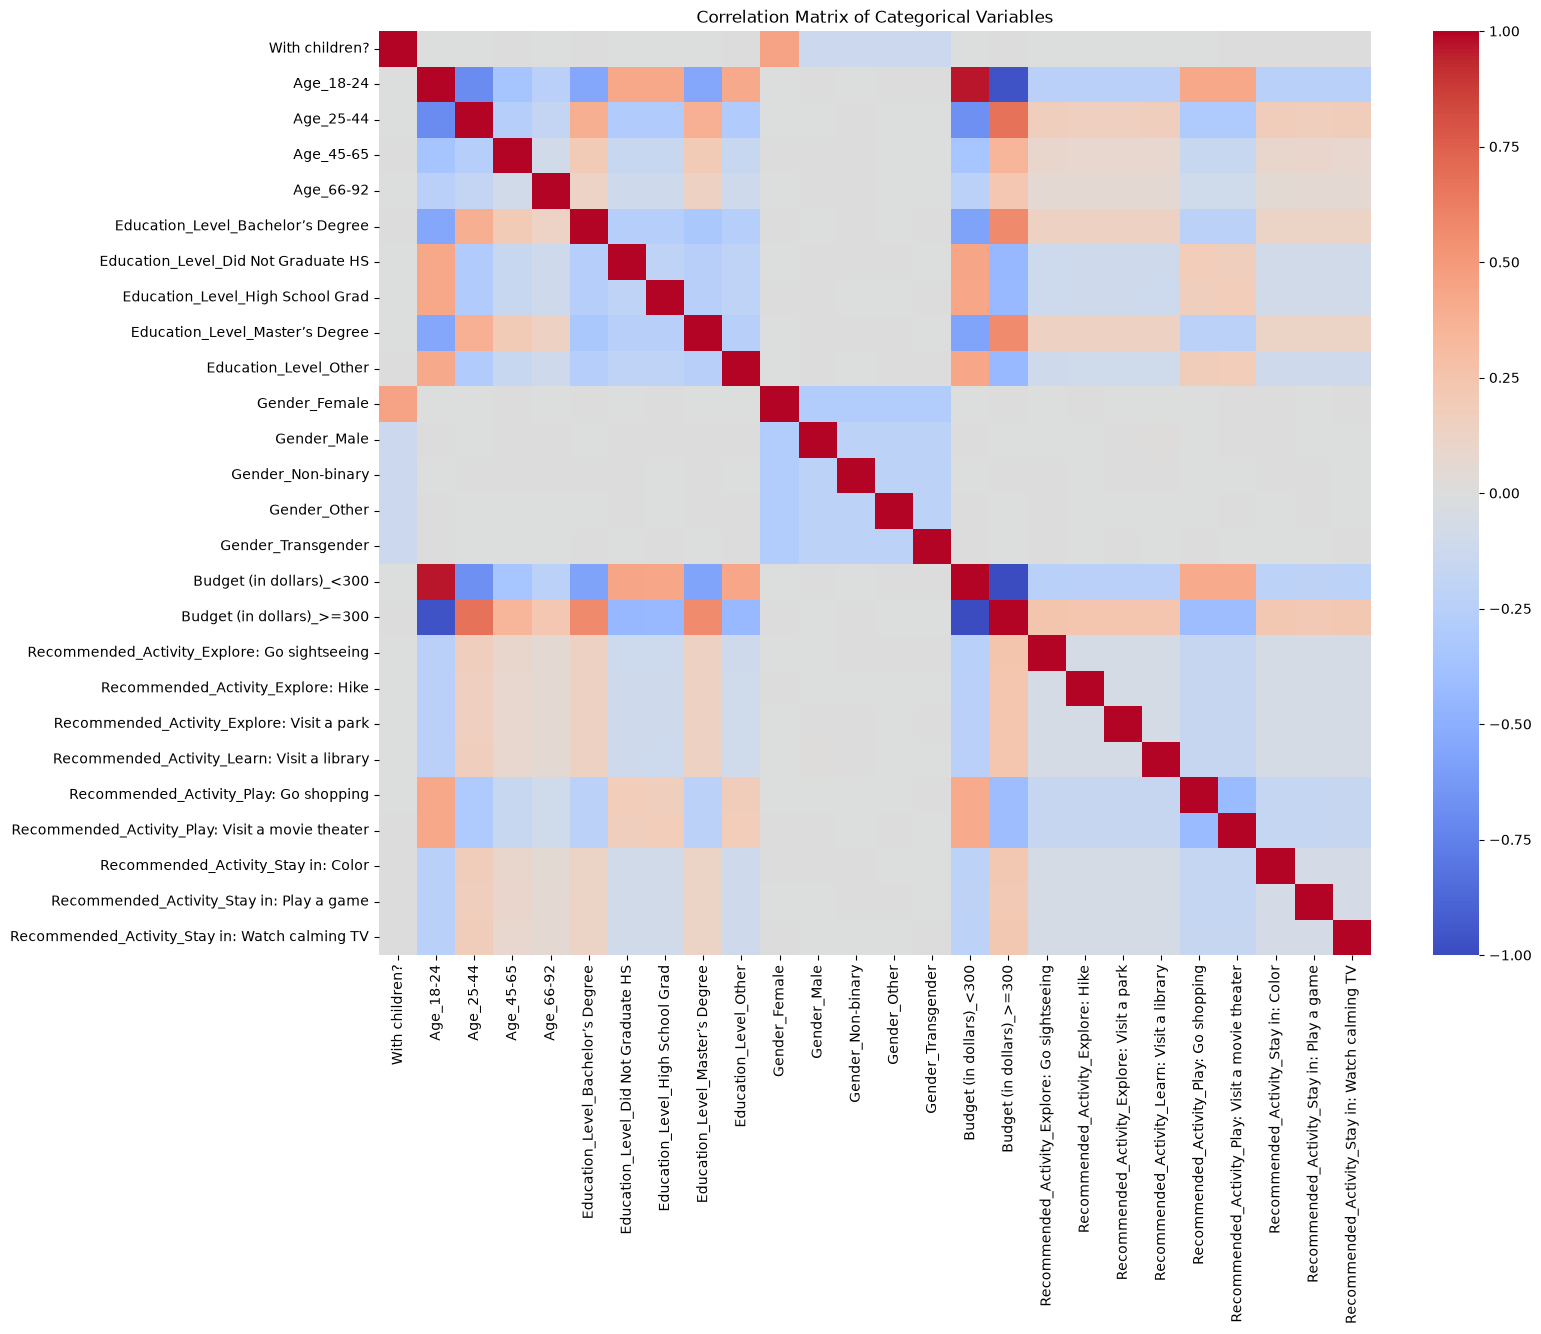

In [7]:
# Plot the correlation matrix
corr_matrix = act_rec_dataset.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1, # dark blue = negative correlation
    vmax=1 # dark red = positive correlation
)
plt.title('Correlation Matrix of Categorical Variables')
plt.show()


Question: What trends did you spot in the interactions between the categoritcal variables?

**Your answer:**

The strongest interaction is between age and budget, with the 18-24 group strongly negatively correlated with a budget >=$300, so younger users are almost always in the <$300 group. The strongest positive correlation is between bachelor’s and master’s graduates and >=$300 budgets, while high school is negatively correlated with >=$300. Age and education are also linked: the 18-24 age group lines up with lower education, so those features are effectively proxies for each other. Gender has almost no correlation with budget or education.

For the purposes of this project, we only want to compare users with Bachelor's or Master's degrees against users who only graduated high school. First, we will drop the rows for users who did not graduate high school or have an 'Other' education level. Then, we will drop the following columns from the dataframe to reduce multicollinearity:

- Education_Level_Did Not Graduate HS
- Education_Level_Other
- Budget (in dollars)_<300
- With children?

In [8]:
# First, drop the rows for people who did not graduate high school or have an "Other" education level
act_rec_dataset = act_rec_dataset[(act_rec_dataset['Education_Level_Did Not Graduate HS'] == 0) & (act_rec_dataset['Education_Level_Other'] == 0)]

#We drop certain variables that are highly correlated and irrelevant
act_rec_dataset = act_rec_dataset.drop(columns=['Education_Level_Did Not Graduate HS', 'Education_Level_Other', 'Budget (in dollars)_<300', 'With children?'])
act_rec_dataset.head()

,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Education_Level_Bachelor’s Degree,Education_Level_High School Grad,Education_Level_Master’s Degree,Gender_Female,Gender_Male,Gender_Non-binary,...,Budget (in dollars)_>=300,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,0,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,0,1,0,0,1,0,0,1,...,1,0,0,0,1,0,0,0,0,0
5,0,1,0,0,1,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
6,0,1,0,0,0,0,1,0,0,1,...,1,1,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0


### Evaluate fairness issues

Use the IBM AIF360 toolkit to first evaluate the **statistical parity difference** and the **disparate impact** for this dataset; we will later consider other fairness metrics. Interpret your findings - is there bias in the proposed problem statement? If yes, what group is benefitting?

**Hint**: Use the BinaryLabelDataset and the BinaryLabelDatasetMetric functions for the fairness evaluation. The reported Statistical Parity Difference may be within -0.64 and -0.55, and the Disparate impact value may be within 0.136 and 0.0150.

In [9]:
# From the problem statement: "IDOOU's creators would like to identify if users with bachelor's
# and master's degrees are a privileged group."

act_rec_dataset['Bachelor_or_Master'] = np.where(
    (act_rec_dataset['Education_Level_Bachelor’s Degree'] == 1) | (act_rec_dataset['Education_Level_Master’s Degree'] == 1),
    1, # 1 if bachelor or master
    0 # 0 if not
)

binary_act_dataset = BinaryLabelDataset(
    df=act_rec_dataset,
    label_names=['Budget (in dollars)_>=300'],
    protected_attribute_names=['Bachelor_or_Master'],
    favorable_label=1,
    unfavorable_label=0
)

privileged_groups = [{'Bachelor_or_Master': 1}]
unprivileged_groups = [{'Bachelor_or_Master': 0}]


In [10]:
orig_metric_act_dataset = BinaryLabelDatasetMetric(
    binary_act_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Statistical Parity Difference =", orig_metric_act_dataset.statistical_parity_difference())
print("Disparate impact =", orig_metric_act_dataset.disparate_impact())


Statistical Parity Difference = -0.9837308661498957
Disparate impact = 0.008865981636453588


Question: Evaluate the fairness metrics. What are your findings? Is there bias in the proposed problem statement? If yes, what group is benefitting?

**Your answer:**

Statistical parity difference is -0.98 (ideal is 0) and disparate impact is 0.0089 (ideal is 1), so there is a strong bias: high-school graduates almost never have a budget >=$300 compared with bachelor’s and master’s graduates. The group benefitting is users with higher education. That matches the earlier plots: higher education correlates with the favorable budget, and those users are overrepresented. This bias is in the dataset labels, not from a trained model. 

## Step 2: Investigate an ML model on the problematic Dataset

For this project, we are using a train-test-validation split.

You have available boilerplate for training 2 ML models on this dataset - you will need to train these models and use the methods we covered in this course to identify and evaluate their performance (**using the accuracy metric and confusion matrix**).

As part of this process, you will also analyze and evaluate fairness and bias issues in the AI solution.

In [11]:
(orig_train,
 orig_validate,
 orig_test) = binary_act_dataset.split([0.5, 0.8], shuffle=True, seed=42)

In [12]:
#Source: Helper code snippet from https://github.com/Trusted-AI/AIF360/blob/master/examples/tutorial_medical_expenditure.ipynb
def test(dataset, model, thresh_arr):
    y_val_pred_prob = model.predict_proba(dataset.features)
    y_val_pred = model.predict(dataset.features)
    pos_ind = np.where(model.classes_ == dataset.favorable_label)[0][0]
    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_val_pred = (y_val_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        dataset_pred = dataset.copy()
        dataset_pred.labels = y_val_pred
        metric = ClassificationMetric(
                dataset, dataset_pred,
                unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)

        metric_arrs['bal_acc'].append((metric.true_positive_rate()
                                     + metric.true_negative_rate()) / 2)
        metric_arrs['avg_odds_diff'].append(metric.average_odds_difference())
        metric_arrs['disp_imp'].append(metric.disparate_impact())
        metric_arrs['stat_par_diff'].append(metric.statistical_parity_difference())
        metric_arrs['eq_opp_diff'].append(metric.equal_opportunity_difference())
        metric_arrs['theil_ind'].append(metric.theil_index())
    
    return metric_arrs, y_val_pred

def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [13]:
GNB_model = GaussianNB().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights) 
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, gnb_pred = test(dataset=orig_test,
                   model=GNB_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9980
Corresponding average odds difference value: -0.5278
Corresponding statistical parity difference value: -0.9934
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0022


Accuracy Gaussian Naive Bayes: 0.9976


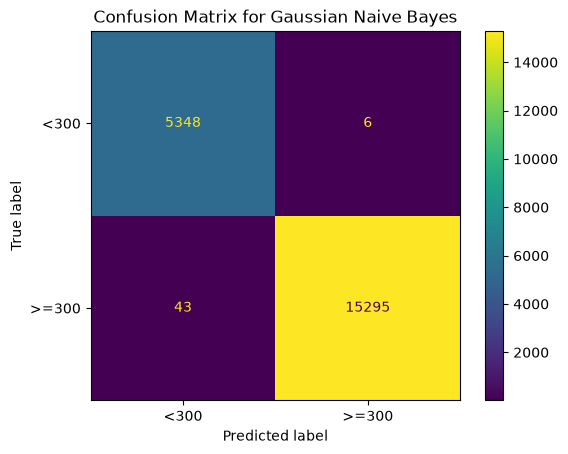

In [14]:
#Evaluate the accuracy of the model
#Visualize the performance (confusion matrix) of the model

accuracy = accuracy_score(orig_test.labels, gnb_pred)
print(f"Accuracy Gaussian Naive Bayes: {accuracy:.4f}")

ConfusionMatrixDisplay.from_predictions(
    orig_test.labels,
    gnb_pred,
    display_labels=['<300', '>=300']
)
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.show()


In [15]:
LR_model = LogisticRegression().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights)

In [16]:
# Load the Logistic Regression model
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, lr_pred = test(dataset=orig_test,
                   model=LR_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.3100
Best balanced accuracy: 0.9980
Corresponding average odds difference value: -0.5278
Corresponding statistical parity difference value: -0.9934
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0022


Accuracy Logistic Regression: 0.9976


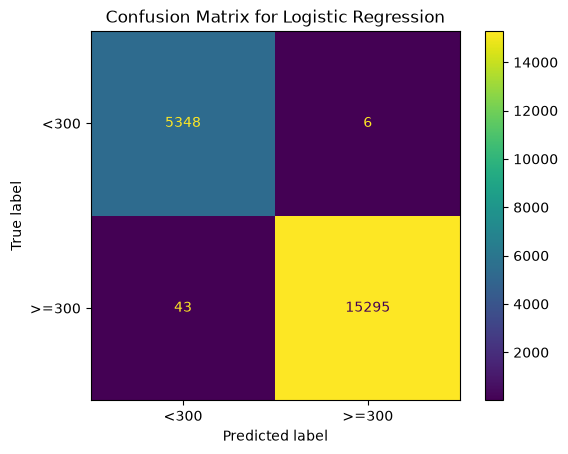

In [17]:
# Evaluate the accuracy of the model
# Visualize the performance (confusion matrix) of the model

accuracy2 = accuracy_score(orig_test.labels, lr_pred)
print(f"Accuracy Logistic Regression: {accuracy2:.4f}")

ConfusionMatrixDisplay.from_predictions(
    orig_test.labels,
    lr_pred,
    display_labels=['<300', '>=300']
)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


In [18]:
# Compare the model accuracy on test dataset either in a bar plot or table format

accuracy_comparison = pd.DataFrame({
    'Model': ['Gaussian Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(orig_test.labels, gnb_pred),
        accuracy_score(orig_test.labels, lr_pred)
    ]
})
accuracy_comparison


,Model,Accuracy
0,Gaussian Naive Bayes,0.997632
1,Logistic Regression,0.997632


In [19]:
#FILL IN Optional
#Compare the fairness metrics on test dataset

Question: Interpret and compare the results of each model. What do you find in the false negative and false positive of each model? What about the fairness metrics?

**Your answer:**

The two models are making the same predictions. Gaussian Naive Bayes and logistic regression have the same test accuracy (0.9976) the same fairness scores and even the two nearly perfect confusion matrices match. The false negatives and false positives are very small.
The fairness scores however are not optimal: Balanced accuracy is 0.9980 (good) and theil index is 0.0022 (so near the ideal 0), but average odds difference is -0.53, statistical parity difference is -0.99, and equal opportunity difference is -1.00 and therefore far from 0 and way outside the band of +/- 0.1 around the 0.
The equal opportunity value of -1 means high school graduates with a budget >=$300 never get that favorable prediction. This concentrates the remaining errors as false negatives on the unprivileged group.


Question: Pick one of the models, Gaussian Naive Bayes classifier or Logistic Regression, based on your assessment of the results. Briefly explain your reason.

**Your answer:**

I pick logistic regression. It has the same accuracy on this pre-processed dataset and also the same fairness scores as the Gaussian Naive Bayes model. There is really no performance reason to prefer either model. Logistic regression would be easier to explain to users in the app (for transparency).

## Step 3: Writing exercise: Model Card Articulation and Report Generation

Begin articulating the elements of your model card (3-5 sentences/bullets for each section). Please delineate bullet points using two hyphens, as show in the example below.

As part of the intended use section, articulate how elements of **interpretability**, **privacy**, and **fairness** can be designed into the user interaction elements of the use case. **Hint:** Should IDOOU prompt the user to check whether the budget predictor model's results are correct?

In [20]:
model_details = """
-- Budget Predicter AI is a model that predicts if the budget is <$300 or >=$300 and is meant to help IDOOU personalize activity recommendations.
-- The model is a Logistic Regression model and predictions are based on features for age, gender, and education level.
-- It has medium ethical AI risk level because it uses personal information of users to make predictions in the app that influence suggestions for activities.
"""
intended_use = """
-- The IDOOU budget predictor is used to suggest activities such as movies, parks, museums, etc. to users based on their budget in the app.
-- It is NOT used for credit scoring, lending, employment, or other sensitive applications.
-- Before making the recommendation, the model should prompt the users to confirm/edit the budget so the human stays in the loop.
-- So the app should show the main factors behind the prediction (e.g. age, education level).
-- Features like gender, age, and educational level are optional inputs and the user can skip those questions and even if the model predicts a budget based on education level, the user confirms or edits the budget so the app does not treat higher education as a requirement for the budget.
"""
factors = """
-- The target is the budget of the user and if it is <$300 or >=$300 with >=$300 being the favorable outcome.
-- The features are gender, age, education level, and recommended activity.
-- The protected attribute is the higher education graduates(so bachelor or master grouped together) vs. high school graduates.
-- Age is binned into 18-24, 25-44, 45-65, and 66-92, and all features are categorical and then one-hot encoded as 0/1.
"""


Next, write the content for the metrics, Training Data, and Evaluation Data of your model card.

In [21]:
metrics = """
-- The metrics for quality that were used are accuracy and confusion matrix of <$300 and >=$300 predictions.
-- Fairness metrics were measured with AIF360's balanced accuracy, statistical parity difference, and disparate impact, average odds difference, equal opportunity difference, and theil index.
-- The logistic regression model had a test accuracy of 0.9976.
-- Ideal values for the fairness are differences ≈ 0, disparate impact ≈ 1, Theil ≈ 0.
"""
training_data = """
-- The original study has about 300k participants, incomplete rows (e.g. with NaNs) were removed before training.
-- The logistic regression model was trained with 51729 rows (50% of the split dataset).
"""
eval_data = """
-- The test set has 20692 rows (20% of the split dataset) and uses the same features and the same >= $300 label as the training set.
-- The validation set has 31038 rows (30% of the split dataset) and uses the same features and the same >= $300 label as the training set.
"""


## Step 4: Use Interpretability mechanisms

Use an interpretability mechanism(s) of your choice, e.g. permutation importance, LIME, etc., to understand the feature importance and model's predictions on the test dataset. **Visualize** and note down the key contributing factors - you will later incorporate this in your model card.

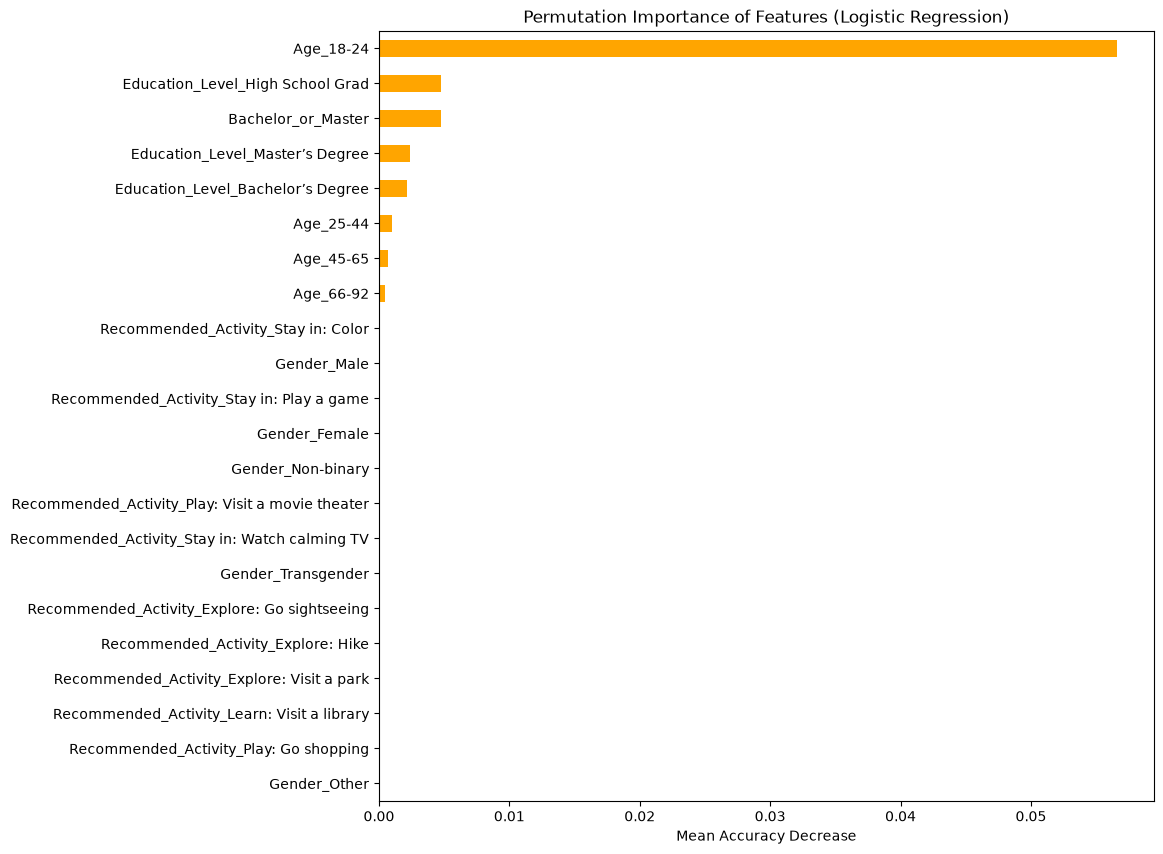

In [22]:
#Use an interpretability mechanism to investigate the AI model you chose

X_test = orig_test.features
y_test = orig_test.labels.ravel() # ravel() converts to 1D array
names = orig_test.feature_names

results = permutation_importance(
    LR_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

importance = pd.Series(results.importances_mean, index=names).sort_values(ascending=True)

plt.figure(figsize=(10, 10))
importance.plot(kind='barh', color=color)
plt.title('Permutation Importance of Features (Logistic Regression)')
plt.xlabel('Mean Accuracy Decrease')
plt.show()


Question: Which interpretability mechanism did you choose? What are the key contributing factors?

**Your answer:**

I chose permutation importance on the logistic regression model. The strongest factor by far is Age_18-24. Next are Education_Level_High School Grad and Bachelor_or_Master, then the bachelor’s and master’s one-hots. Shuffling those drops accuracy the most, which matches young users and high-school graduates being tied to a <$300 budget. Gender and recommended activity have almost no influence. After Reject Option Classification the ranking stays the same, because it does not retrain the model (it only flips some labels).


## Step 5: Apply a bias mitigation strategy

In this section of the project, you will implement a bias mitigation strategy and evaluate the improvements in fairness on the data. Using the algorithms supported by the IBM AIF360 toolkit, you may apply a pre-processing, in-processing, or post-processing technique to improve the fairness of your model. Optionally, you may also consider combining multiple techniques.

**Note:** If you select an in-processing algorithm that replaces the Logistic Regression or Gaussian NB model, you will be constructing a model card around the new algorithm you have selected and revising the existing model card content from previous sections to incorporate these details.

In [23]:
# Implement bias mitigation strategy

def add_scores(dataset, model, pos_ind):
    d = dataset.copy(deepcopy=True)
    d.scores = model.predict_proba(d.features)[:, pos_ind].reshape(-1, 1)
    d.labels = model.predict(dataset.features).reshape(-1, 1)
    return d

pos_ind = np.where(LR_model.classes_ == orig_test.favorable_label)[0][0]

val_dataset = add_scores(orig_validate, LR_model, pos_ind)
test_dataset = add_scores(orig_test, LR_model, pos_ind)

rej_opt_classifier = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    metric_name="Average odds difference",
    metric_ub=0.05, # 5% difference
    metric_lb=-0.05 # 5% difference
)

rej_opt_classifier.fit(orig_validate, val_dataset)
test_pred = rej_opt_classifier.predict(test_dataset)


In [24]:
# Obtain the new metric values after applying your bias mitigation strategy

metric = ClassificationMetric(
    orig_test,
    test_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

mitigated_metrics = {
    'bal_acc': [(metric.true_positive_rate() + metric.true_negative_rate()) / 2],
    'avg_odds_diff': [metric.average_odds_difference()],
    'stat_par_diff': [metric.statistical_parity_difference()],
    'eq_opp_diff': [metric.equal_opportunity_difference()],
    'theil_ind': [metric.theil_index()],
}

describe_metrics(mitigated_metrics, np.array([rej_opt_classifier.classification_threshold]))


Threshold corresponding to Best balanced accuracy: 0.1783
Best balanced accuracy: 0.9848
Corresponding average odds difference value: -0.0828
Corresponding statistical parity difference value: -0.9571
Corresponding equal opportunity difference value: -0.1395
Corresponding Theil index value: 0.0032


**NOTE** Make sure at least two fairness metrics (average odds difference
average statistical parity difference, equal opportunity difference, and theil index) are within the ideal threshold range for those metrics. A slightly higher benefit for the privileged group may still be seen, which is ok.

Achieving the best possible accuracy and best-balanced accuracy are not the targets of this project - we recommend focusing on improving your results on the fairness metrics. It is recommended to have your balanced accuracy between 85%-100% but not required.

**IMPORTANT! If less than two fairness metrics are within the ideal range, re-work on your strategy.**

Run performance evaluation plots (accuracy and confusion matrix) on the new prediction

Accuracy after ROC: 0.9919


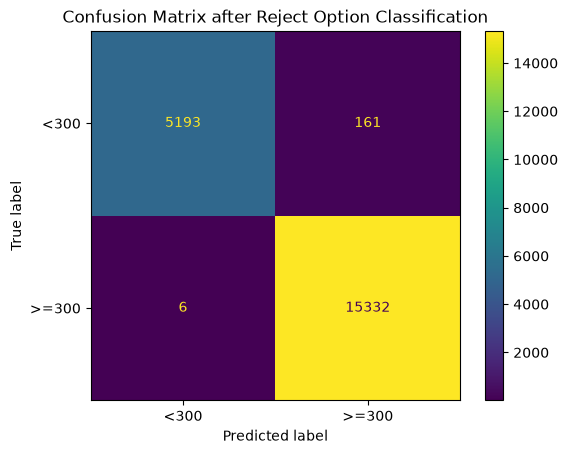

In [25]:
# Run performance evaluation plots (accuracy and confusion matrix) on the new prediction

print(f"Accuracy after ROC: {accuracy_score(orig_test.labels, test_pred.labels):.4f}")

ConfusionMatrixDisplay.from_predictions(
    orig_test.labels,
    test_pred.labels,
    display_labels=['<300', '>=300']
)
plt.title('Confusion Matrix after Reject Option Classification')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()


Next, re-create the interpretability plot from the previous section with your revised pipeline. 

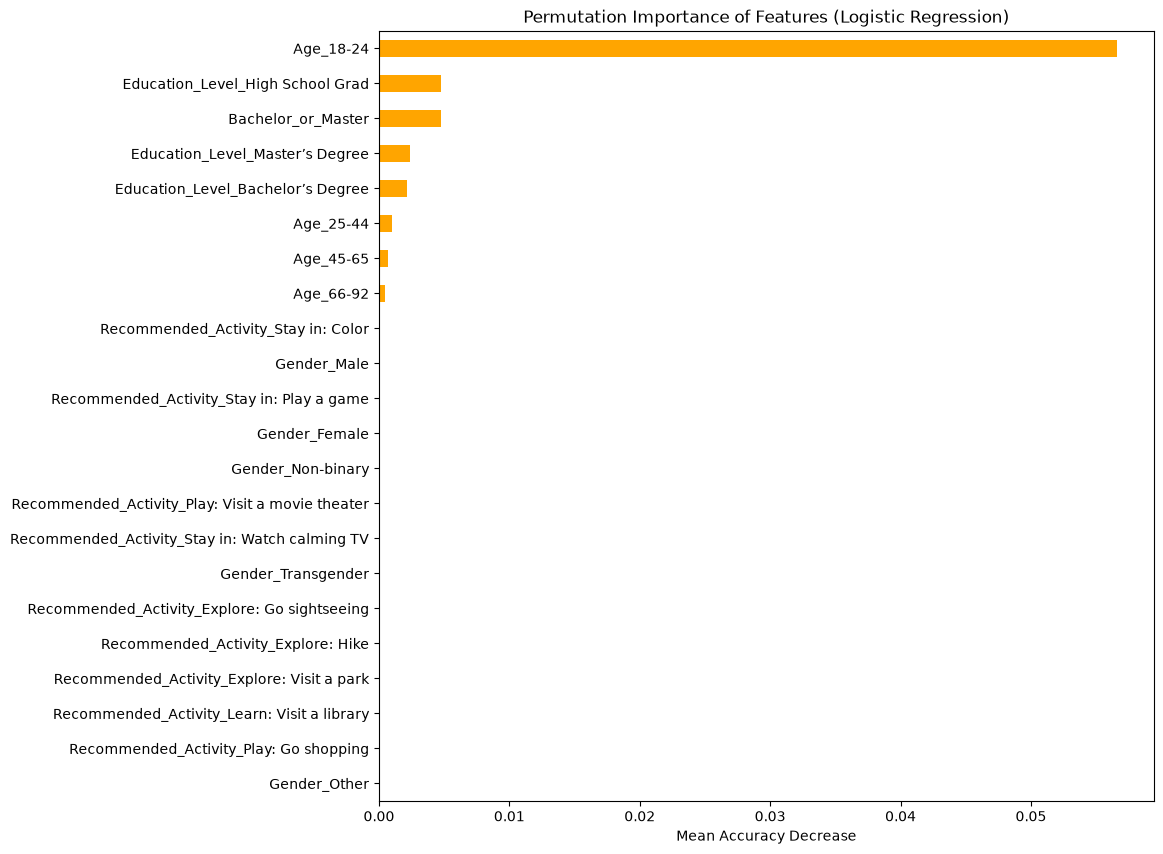

In [26]:
# Re-create the interpretability plot with the revised pipeline

X_test = orig_test.features
y_test = orig_test.labels.ravel()
names = orig_test.feature_names

results = permutation_importance(
    LR_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

importance = pd.Series(results.importances_mean, index=names).sort_values(ascending=True)

plt.figure(figsize=(10, 10))
importance.plot(kind='barh', color=color)
plt.title('Permutation Importance of Features (Logistic Regression)')
plt.xlabel('Mean Accuracy Decrease')
plt.savefig('permutation_importance.png', bbox_inches='tight')
plt.show()


Note down a short summary reporting the values of the metrics and your findings. This will be the quantitative analysis section of the model card.
- Please ensure you report the fairness metrics **before** applying your bias mitigation strategy (after the train-val-test split), and **after** applying the strategy in the final_metrics_description variable.
- Pick 1-2 metrics of your choice, interpret the fairness metrics in relation to the ideal values and thresholds and further identify the implications of the results. 

In [27]:
final_metrics_description = """
-- Before applying the bias mitigation strategy, the model had a balanced accuracy of 0.9980 but unfair: average odds difference was -0.5278, equal opportunity difference was -1.0000 (0 would have been ideal).
-- After applying Reject Option Classification, the model had a balanced accuracy of 0.9848, average odds difference improved to -0.0828 (inside the +/- 0.1 band around 0), equal opportunity difference improved to -0.1395 (slightly outside the +/- 0.1 band around 0).
-- Statistical parity difference almost stayed the same (-0.9934 vs. -0.9571) resulting higher education users still being classified as >=$300 much more than high school users.
-- Theil index stayed close to 0 (0.0022 vs. 0.0032) and permutation importance of features stayed the same (Age_18-24 and higher education still the most important).
"""


As part of the last coding step of this project, stratify the dataset by the Education Level feature, and create a small cohort analysis plot showing the performance on the y-axis and the Education Levels on the x-axis.

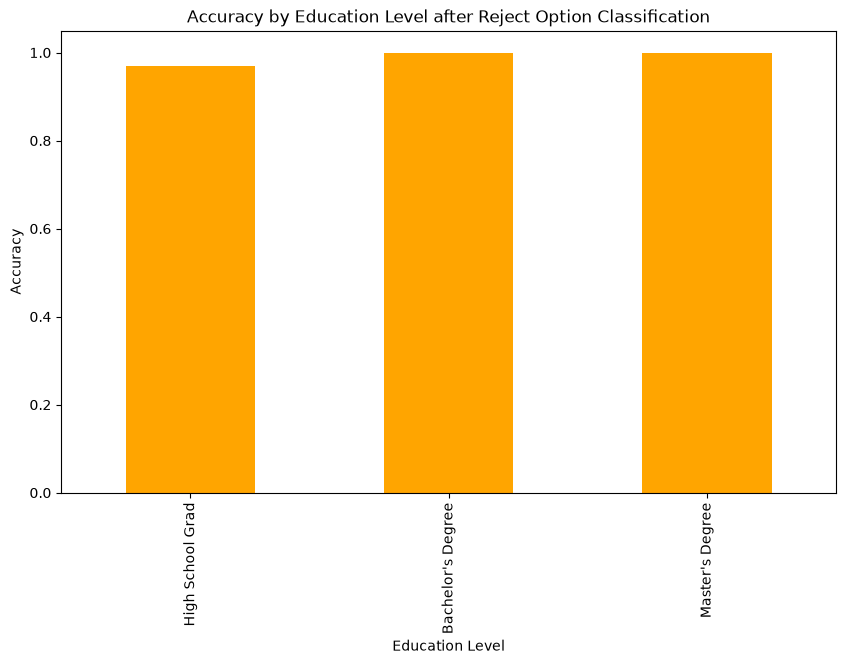

In [28]:
test_df = pd.DataFrame(orig_test.features, columns=orig_test.feature_names)
test_df['y_true'] = orig_test.labels.ravel()
test_df['y_pred'] = test_pred.labels.ravel()

bachelor = test_df['Education_Level_Bachelor’s Degree'] == 1
master = test_df['Education_Level_Master’s Degree'] == 1
high_school = test_df['Education_Level_High School Grad'] == 1

test_df['Education'] = np.select(
    [bachelor, master, high_school],
    ["Bachelor's Degree", "Master's Degree", "High School Grad"],
    default="Other"
)

cohort_accuracy = (
    test_df.groupby('Education')
    .apply(lambda x: accuracy_score(x['y_true'], x['y_pred']))
    .reindex(["High School Grad", "Bachelor's Degree", "Master's Degree"])
)

plt.figure(figsize=(10, 6))
cohort_accuracy.plot(kind='bar', color=color)
plt.title('Accuracy by Education Level after Reject Option Classification')
plt.xlabel('Education Level')
plt.ylabel('Accuracy')
plt.savefig('accuracy_by_education.png', bbox_inches='tight')
plt.show()


**Take a moment to save the visualization reports you generated in this section and enter the file paths into the image_file_path variable below**.

In [29]:
# Plots were saved in the cells that create them.

image_file_path ="""
  <img src="confusion_matrix.png"><br/>
  <img src="permutation_importance.png"><br/>
  <img src="accuracy_by_education.png"><br/>
"""


**Optional**: You may choose to create a cohort analysis plot showing the fairness metric values on the y-axis and the Education Levels on the x-axis.

In [30]:
#Optional save image for the fairness corhort analysis
#plt.savefig('images/optional_fairness_cohort_analysis') 

## Step 6: Articulate the ethical implications

Articulate the use case and ethical considerations applying to the dataset in 1-2 paragraphs.

**Hints:** 
 
- Think about the limitations of the dataset, potential biases that could be introduced into the use case, and the strengths and weaknesses of your ML model.
- Ethical Considerations:
 - Human-in-the-loop considerations: Can users control aspects of the model and inspect the features? If so, briefly describe how?
 - Describe the limitations and types of bias present in the data
 - Describe the failures of the ML model
 - It must include a section on any risk mitigation strategies you applied.
 - Describe Potential harms
 - It must include key contributing factors you found from your interpretability study, both before and after applying the bias mitigation strategy.

- Caveats and Recommendations
 - Potential lack of inclusiveness in the dataset
 - Predisposition of the model to false positives and/or negatives
 - It must also include 1-2 sentences on the further ethical AI analyses you would apply if given more time beyond this project.

In [31]:
ethical_considerations="""
-- Users should confirm or edit the predicted budget and see the main factors that led to the prediction (e.g. age, education level).
-- The data has a selection bias: the 18-24 age group as well as the higher education group are overrepresented.
-- The logistic regression model treats the 18-24 age group and the high school graduates as the same with a <$300 budget so high school graduates are overrepresented in the <$300 group.
-- I used Reject Option Classification because it is post-processing: it keeps the logistic regression model and flips some labels in a confidence band without retraining and as a result permutation importance still ranks Age_18-24 first both before and after ROC.
-- Recommending expensive activities to a user that could not afford it (false positive for >=$300) could potentially harm the user.
"""
caveats_and_recommendations="""
-- The training data is not inclusive of older users and users with lower education levels and dropping incomplete rows removed every user that skipped gender, age, or education.
-- The model still treats high school users as <$300, but after Reject Option Classification the confusion matrix has 161 false positives and only 6 false negatives, so a false positive is worse because it could recommend activities the user cannot afford.
-- Further ethical AI analyses I would apply beyond this project: plot fairness metrics by age and education, possibly combine Reject Option Classification with re-weighting or re-sampling.
"""

- Business consequences
 - Potential positive impact of the IDOOU Budget Predicter AI
 - Reasons why users may lose trust in the application, and loss of revenue and brand reputation might occur to the organization

In [32]:
business_consequences="""

-- Positive Impact: The upside for IDOOU is that the model can help them personalize activity recommendations and better match the activities to the user's budget increasing engagement and revenue.

-- Negative Impact: If the budget is predicted incorrectly the business could lose revenue (false negative for >=$300) or the user could have a harmful experience (false positive for >=$300) with users losing trust in the app and brand reputation could suffer.
"""

## Document the solution in a model card

You're at the finish line! Run the last few blocks of code to generate a simple html file with your model card content and the visualizations you generated for the final version of your model.

Make sure to open the html file and check that it is reflective of your model card content before submitting.

Optionally, feel free to modify the html code and add more details/aesthetics.

In [33]:
html_code = f"""
<html>
  <head>
    <meta charset="UTF-8">
  </head>
  <body>
  <center><h1>Model Card - IDOOU AI Budget Predicter</h1></center>
  <h2>Model Details</h2>
  {model_details}
  <h2>Intended Use</h2>
  {intended_use}
  <h2>Factors</h2>
  {factors}
  <h2>Metrics</h2>
  {metrics}
  <h2> Training Data </h2>
  {training_data}
  <h2> Evaluation Data </h2>
  {eval_data}
  <h2>Quantitative Analysis</h2>
  {final_metrics_description}
  
  <br/><br/><b>Results of the AI model after applying the bias mitigation strategy</b><br/>
  
  <center>
  {image_file_path}
  </center>

  <h2>Ethical Considerations</h2>
  {ethical_considerations}
  <h2>Caveats and Recommendations</h2>
  {caveats_and_recommendations}
  <h2>Business Consequences</h2>
  {business_consequences}
  </body>
</html>"""
html_code = html_code.replace('--', '<br>--')

In [34]:
with open('model_card.html', 'w') as f:
    f.write(html_code)

Download and zip the .html report, the images you generated, and this Jupyter notebook, and you're ready for submission!